In [31]:
import configargparse
from pathlib import Path
from torch.utils.data import DataLoader
from models.gnn import GNNPolicy
from models.split import SplitBlockBiJepaPolicy
from data.datasets import GraphDataset, pad_collate_graphs, PadFeaturesTransform
from data.split import SplitInstanceDataset, split_instance_collate
from data.common import CONS_PAD, VARS_PAD
import torch
import pickle
import numpy as np

In [54]:
# --- Paths ---
# Unsplit GNN model (CA-200, full finetune)
UNSPLIT_CKPT = Path("/home/joachim-verschelde/Repos/KKT_MPNN/src/experiments/gnn_finetuning/finetune_CA_200/finetune_CA_200_gnn_full_finetune/gnn_finetuning/run_gnn_policy-gv=2-lv=8-slice=512-point=13-lmbd=0.256-std=0.0-dim=128-l_mask=0.6-g_mask=0.05-l_e_mask=0.05-g_e_mask=0.6-dp=0.05-l_dim=128-conv=gatv2-heads=4_20260408_014039/best.pt")

# Split model (CA, full finetune)
SPLIT_CKPT = Path("/home/joachim-verschelde/Repos/KKT_MPNN/src/experiments/split_bijepa_finetuning/finetune_split_CA_200_COMPOSER_h0/best.pt")

# Test instance (CA-100)
BG_FILE = "../data/instances/milp/finetune/CA/BG/test/100/CA-100-0000.lp.bg"
SPLIT_FILE = "../data/instances/milp/finetune/CA/splits/halo-0-blocks-5/test/100/CA-100-0000.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [55]:
# --- Load unsplit GNN model ---
unsplit_pkg = torch.load(str(UNSPLIT_CKPT), map_location="cpu")
unsplit_args = configargparse.Namespace(**unsplit_pkg["args"])

unsplit_model = GNNPolicy(unsplit_args).to(device)
unsplit_model.load_state_dict(unsplit_pkg["model"])
unsplit_model.eval()
print(f"Unsplit model loaded from step {unsplit_pkg.get('step', '?')}")
print(f"  params: {sum(p.numel() for p in unsplit_model.parameters()):,}")

Unsplit model loaded from step 19500
  params: 604,232


In [56]:
# --- Load split model ---
split_pkg = torch.load(str(SPLIT_CKPT), map_location="cpu")
split_args = configargparse.Namespace(**split_pkg["args"])

split_model = SplitBlockBiJepaPolicy(split_args).to(device)
split_model.load_state_dict(split_pkg["model"])
split_model.eval()
print(f"Split model loaded from step {split_pkg.get('step', '?')}")
print(f"  params: {sum(p.numel() for p in split_model.parameters()):,}")

Split model loaded from step 4500
  params: 1,137,992


In [67]:
# --- Run unsplit GNN on the BG file ---
dataset = GraphDataset([BG_FILE], transform=PadFeaturesTransform(CONS_PAD, VARS_PAD))
loader = DataLoader(dataset, batch_size=1, shuffle=False, collate_fn=pad_collate_graphs)

with torch.no_grad():
    for batch in loader:
        bg, A, b, c, mask_m, mask_n, m_sizes, n_sizes, sample_paths = batch
        bg = bg.to(device)
        x_unsplit, lam_unsplit = unsplit_model(
            bg.constraint_features, bg.edge_index, bg.edge_attr, bg.variable_features
        )
        x_unsplit = x_unsplit.cpu()
        lam_unsplit = lam_unsplit.cpu()

# Round x predictions: >= 0.5 -> 1, < 0.5 -> 0
x_unsplit = (x_unsplit >= 0.25).float()

n_vars = int(mask_n[0].sum().item())
n_cons = int(mask_m[0].sum().item())
print(f"Unsplit prediction: {n_vars} variables, {n_cons} constraints")
print(f"  x range: [{x_unsplit[:n_vars].min():.4f}, {x_unsplit[:n_vars].max():.4f}]")
print(f"  lam range: [{lam_unsplit[:n_cons].min():.4f}, {lam_unsplit[:n_cons].max():.4f}]")

Unsplit prediction: 200 variables, 536 constraints
  x range: [0.0000, 1.0000]
  lam range: [0.0000, 244.5203]


In [68]:
# --- Run split model on the split .pt file ---
split_inst = torch.load(SPLIT_FILE, map_location="cpu")

with torch.no_grad():
    x_split, lam_split = split_model.predict_instance(split_inst)
    x_split = x_split.cpu()
    lam_split = lam_split.cpu()

# Round x predictions: >= 0.5 -> 1, < 0.5 -> 0
x_split = (x_split >= 0.25).float()

print(f"Split prediction: {split_inst.n_vars} variables, {split_inst.n_cons} constraints")
print(f"  x range: [{x_split.min():.4f}, {x_split.max():.4f}]")
print(f"  lam range: [{lam_split.min():.4f}, {lam_split.max():.4f}]")

Split prediction: 200 variables, 536 constraints
  x range: [0.0000, 1.0000]
  lam range: [0.0000, 291.5429]


In [69]:
# --- Load optimal solution ---
solution_path = BG_FILE.replace("BG", "solution").replace(".bg", ".sol")
with open(solution_path, "rb") as f:
    solution_data = pickle.load(f)

# Reorder solution to match BG variable order
from metrics.optimization import load_optimal_solutions
optimal_pool = load_optimal_solutions(instance_path=BG_FILE)
optimal = optimal_pool[0].numpy() if optimal_pool is not None else None

if optimal is not None:
    print(f"Optimal solution loaded: {len(optimal)} variables")
    print(f"  Optimal obj: {solution_data['objs'].min():.4f}")
else:
    print("No optimal solution found")

Optimal solution loaded: 200 variables
  Optimal obj: -6468.5245


In [70]:
# --- Compare predictions side by side ---
n = min(n_vars, split_inst.n_vars, len(optimal) if optimal is not None else 999)

# Load c_vec for objective computation
with open(BG_FILE, "rb") as f:
    _, _, _, _, _, _, c_vec = pickle.load(f)
c_np = np.asarray(c_vec, dtype=np.float32)[:n]

x_u = x_unsplit[:n].numpy()
x_s = x_split[:n].numpy()
x_opt = optimal[:n] if optimal is not None else np.zeros(n)

obj_unsplit = float(c_np @ x_u)
obj_split = float(c_np @ x_s)
obj_optimal = float(c_np @ x_opt)

print(f"{'':>6} | {'Unsplit':>10} | {'Split':>10} | {'Optimal':>10}")
print("-" * 50)
for i in range(min(n, 20)):  # show first 20 variables
    print(f"x[{i:3d}] | {x_u[i]:10.4f} | {x_s[i]:10.4f} | {x_opt[i]:10.4f}")
if n > 20:
    print(f"  ... ({n - 20} more variables)")

print(f"\n{'Objective':>6} | {obj_unsplit:10.4f} | {obj_split:10.4f} | {obj_optimal:10.4f}")
print(f"{'Gap %':>6} | {abs(obj_unsplit - obj_optimal) / (abs(obj_optimal) + 1e-9) * 100:9.2f}% | {abs(obj_split - obj_optimal) / (abs(obj_optimal) + 1e-9) * 100:9.2f}% |       0.00%")

       |    Unsplit |      Split |    Optimal
--------------------------------------------------
x[  0] |     1.0000 |     1.0000 |     1.0000
x[  1] |     0.0000 |     0.0000 |     0.0000
x[  2] |     0.0000 |     0.0000 |     0.0000
x[  3] |     0.0000 |     0.0000 |     1.0000
x[  4] |     0.0000 |     0.0000 |     0.0000
x[  5] |     0.0000 |     0.0000 |     0.0000
x[  6] |     0.0000 |     0.0000 |     0.0000
x[  7] |     0.0000 |     0.0000 |     0.0000
x[  8] |     0.0000 |     1.0000 |     1.0000
x[  9] |     0.0000 |     0.0000 |     0.0000
x[ 10] |     0.0000 |     0.0000 |     0.0000
x[ 11] |     0.0000 |     0.0000 |     0.0000
x[ 12] |     0.0000 |     0.0000 |     0.0000
x[ 13] |     0.0000 |     0.0000 |     1.0000
x[ 14] |     1.0000 |     1.0000 |     0.0000
x[ 15] |     0.0000 |     0.0000 |     1.0000
x[ 16] |     0.0000 |     0.0000 |     0.0000
x[ 17] |     0.0000 |     0.0000 |     0.0000
x[ 18] |     0.0000 |     1.0000 |     0.0000
x[ 19] |     1.0000 |     0.0

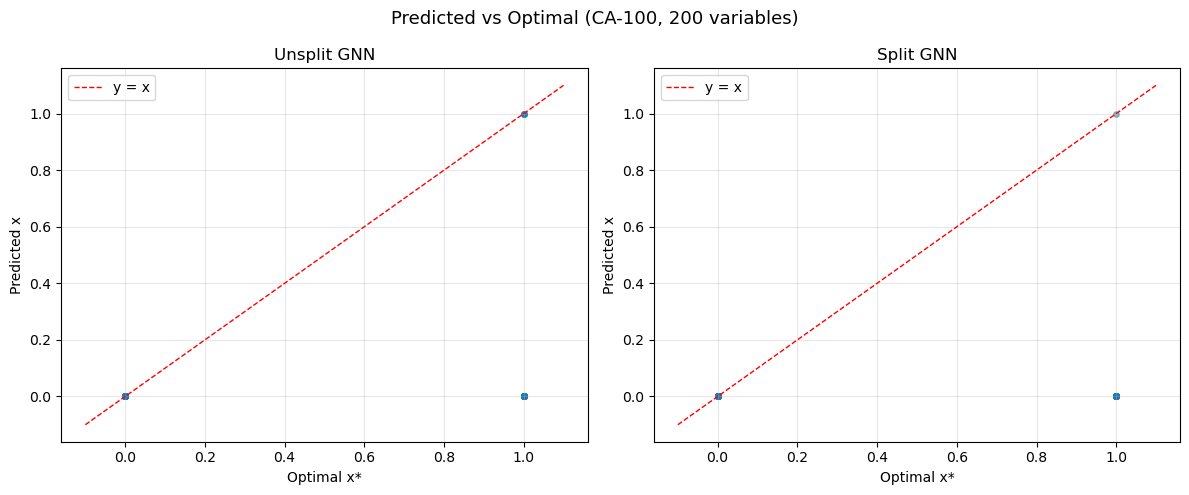

In [61]:
# --- Scatter plot: predicted vs optimal ---
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, x_pred, title in [
    (axes[0], x_u, "Unsplit GNN"),
    (axes[1], x_s, "Split GNN"),
]:
    ax.scatter(x_opt, x_pred, alpha=0.5, s=15)
    lo = min(x_opt.min(), x_pred.min()) - 0.1
    hi = max(x_opt.max(), x_pred.max()) + 0.1
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=1, label="y = x")
    ax.set_xlabel("Optimal x*")
    ax.set_ylabel("Predicted x")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle(f"Predicted vs Optimal (CA-100, {n} variables)", fontsize=13)
fig.tight_layout()
plt.show()